In [1]:
# Jaxlib
import jax
from jax import lax
from jax import random as jrnd
from jax import numpy as jnp
from jax import tree_util as jtu
jax.config.update('jax_enable_x64', True)

# Others
from matplotlib import pyplot as plt
import os

from numerics import *

Phase 1: Eigs etc.

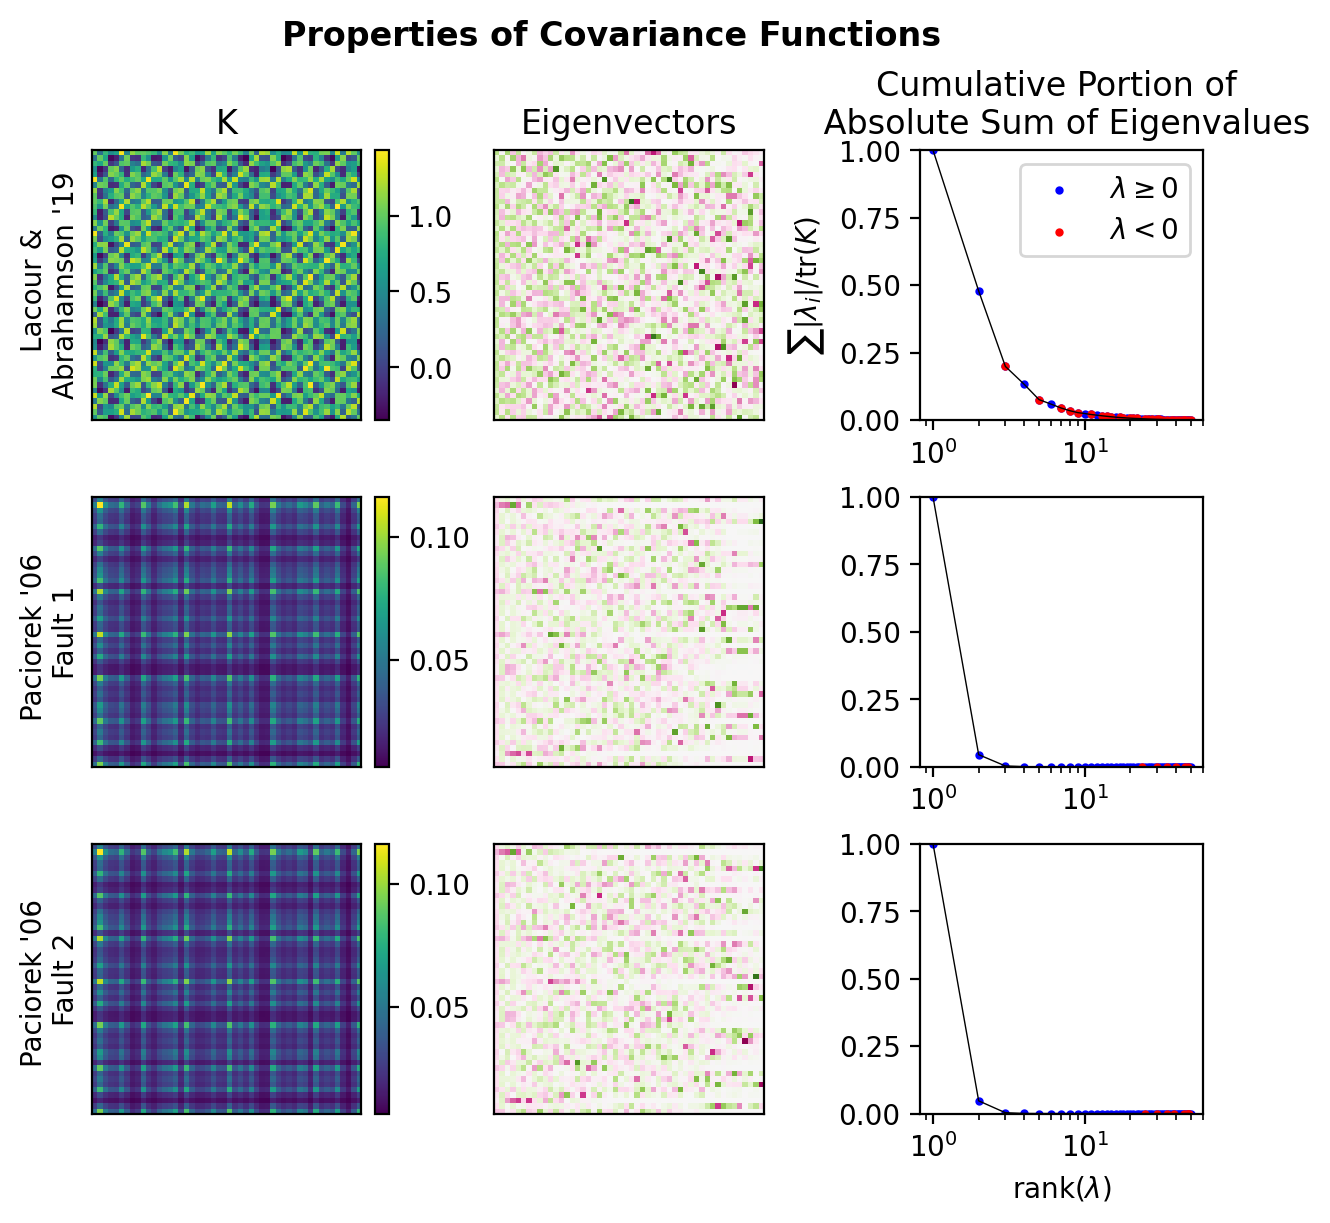

In [2]:
# Decay plot
path_Lacour = 'test_outputs/phase1/scn%s_K_Lacour.npz'%1
path_Paciorek1 = 'test_outputs/phase1/scn%s_K_Paciorek_meansp.npz'%1
path_Paciorek2 = 'test_outputs/phase1/scn%s_K_Paciorek_meansp.npz'%2

def plot_cov_birdseye(savepath = None):
    fig,ax = plt.subplots(3, 3, figsize = (6, 6), layout = 'constrained', dpi = 200)

    for i,(path,name) in enumerate(zip([path_Lacour, path_Paciorek1, path_Paciorek2], 
                                ["Lacour & \nAbrahamson '19", "Paciorek '06 \nFault 1", "Paciorek '06 \nFault 2"])):
        data = jnp.load(path)
        K, eigvals, eigvecs = [data[file] for file in data.files]
        eigvals, eigvecs = eigvals.real, eigvecs.real
        eigvecs = eigvecs / jnp.abs(eigvecs).max()

        # Kernel image
        K_img = ax[i,0].imshow(K)
        plt.colorbar(K_img)
        ax[i,0].set_xticks([])
        ax[i,0].set_yticks([])
        ax[i,1].set_xticks([])
        ax[i,1].set_yticks([])

        # Eigenvectors
        ax[i,1].imshow(eigvecs.real, cmap = 'PiYG', vmin = -1, vmax = 1)

        # Eigenvalue decay
        eigsort = jnp.argsort(jnp.abs(eigvals))
        eigvals = eigvals[eigsort]
        eigsign = jnp.sign(eigvals)
        eigidx = jnp.arange(eigvals.shape[0]) + 1
        eigsum = jnp.cumsum(jnp.abs(eigvals))
        eigsum /= eigsum.max()
        ax[i,2].plot(eigidx, eigsum[::-1], c = 'k', lw = 0.5)
        ax[i,2].scatter(eigidx, eigsum[::-1], c = 'b', s = 4, label = r'$\lambda \geq 0$')
        ax[i,2].scatter(eigidx[eigsign[::-1] < 0], eigsum[::-1][eigsign[::-1] < 0], c = 'r', s = 4, label = r'$\lambda < 0$')
        ax[i,2].set_xscale('log')
        ax[i,2].set_ylim(0, 1)

        if i == 0:
            ax[i, 0].set_title('K')
            ax[i, 1].set_title('Eigenvectors')
            ax[i, 2].set_title('Cumulative Portion of \n Absolute Sum of Eigenvalues')
            ax[i, 2].set_ylabel(r'$\sum |\lambda_i| / \text{tr}(K)$')
            ax[i, 2].legend()
        if i == 2:
            ax[2,2].set_xlabel('rank'+r'$(\lambda)$')
        ax[i, 0].set_ylabel(name)
    plt.suptitle('Properties of Covariance Functions', fontweight = 'bold')
    if savepath is None:
        plt.show()
    else:
        plt.savefig(savepath)
        plt.close()

plot_cov_birdseye()

In [3]:
def plot_eigfns(savepath = None):
    # Eigenfunction display
    data = jnp.load('test_outputs/phase1/M_lnR_R_enum.npz')
    M_enum, lnR_enum, R_enum = [data[file] for file in data.files]
    for A_enum in [M_enum, R_enum]:
        print(A_enum.min(), A_enum.max())
    MlnR_enum = jnp.stack([M_enum, lnR_enum], axis = -1)
    n_gr = 150
    k_KL = 6
    M_gr= jnp.linspace(M_enum.min(), M_enum.max(), n_gr)
    lnR_gr = jnp.linspace(lnR_enum.min(), lnR_enum.max(), n_gr)
    MlnR_gr = jnp.stack(jnp.meshgrid(M_gr, lnR_gr), axis = -1).reshape(n_gr**2, 2)

    for i,(path,name,titlestr,pathstr) in enumerate(zip([path_Lacour, path_Paciorek1, path_Paciorek2], 
                                ["Lacour & \nAbrahamson '19", "Paciorek '06 \nFault 1", "Paciorek '06 \nFault 2"],
                                ["from Lacour & Abrahamson 2019", "Inspired by Paciorek 2006 (Fitted to Fault 1)", "Inspiredy by Paciorek 2006 (Fitted to Fault 2)"],
                                ["Lacour19, Paciorek06_1, Paciorek06_2"])):
        fig,ax = plt.subplots(3, 2, figsize = (4, 6), sharex = True, sharey = True,
                            layout = 'constrained', dpi = 200)
        fig.get_layout_engine().set(hspace=0.00, wspace=0.05)
        data = jnp.load(path)
        K, eigvals, eigvecs = [data[file] for file in data.files]
        eigvals, eigvecs = eigvals.real, eigvecs.real
        top_k_eigvecs = eigvecs[:,:k_KL]
        eigfns = rbf_interpolator(MlnR_enum, top_k_eigvecs, 3, 3)
        eiggrid = eigfns(MlnR_gr).reshape(n_gr, n_gr, k_KL)
        for ij in range(k_KL):
            i,j = ij // 2, ij % 2
            eiggrid_ij = eiggrid[:, :, ij]
            eiggrid_ij /= jnp.abs(eiggrid_ij).max()
            eigimg = ax[i,j].pcolormesh(M_gr, jnp.exp(lnR_gr), eiggrid_ij, 
                            vmin = -1, vmax = 1, cmap = 'rainbow')
            ax[i,j].set_yscale('log')
            ax[i,j].set_aspect('auto')
            ax[i,j].set_title(rf'$\lambda_{{{ij+1}}}$')
            if i == 2:
                ax[i,j].set_xlabel('M')
            if j == 0:
                ax[i,j].set_ylabel('R (km)')
        cax = fig.add_axes((0.2, -0.05, 0.6, 0.025))
        plt.colorbar(eigimg, cax, orientation = 'horizontal')
        plt.suptitle('First Six Unit-Scaled Eigenfunctions of Kernel \n%s'%titlestr, fontweight = 'bold')
        if savepath is None:
            plt.show()
        else:
            plt.savefig(savepath + '_%s'%pathstr)
            plt.close()

Phase 2: Hazard Curves